In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import title

In [2]:
df=pd.read_csv('matches.csv')
print(df.shape)
print(df.info())
print(df.describe())

(1095, 20)
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method        

In [3]:
print(f"Seasons  : {df['season'].unique()}")
print(f"Teams    : {pd.unique(df[['team1','team2']].values.ravel())}")
print(f"Venues   : {df['venue'].nunique()} unique venues")

Seasons  : <StringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024']
Length: 17, dtype: str
Teams    : ['Royal Challengers Bangalore' 'Kolkata Knight Riders' 'Kings XI Punjab'
 'Chennai Super Kings' 'Delhi Daredevils' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Rising Pune Supergiants' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Delhi Capitals' 'Punjab Kings'
 'Lucknow Super Giants' 'Gujarat Titans' 'Royal Challengers Bengaluru']
Venues   : 58 unique venues


In [4]:
df.isnull().sum()


id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [5]:

# count nulls and convert to percentage
null_series = df.isnull().sum()
null_pct = (null_series / len(df) * 100).round(2)
null_pct

id                  0.00
season              0.00
city                4.66
date                0.00
match_type          0.00
player_of_match     0.46
venue               0.00
team1               0.00
team2               0.00
toss_winner         0.00
toss_decision       0.00
winner              0.46
result              0.00
result_margin       1.74
target_runs         0.27
target_overs        0.27
super_over          0.00
method             98.08
umpire1             0.00
umpire2             0.00
dtype: float64

                 missing_count  missing_pct
target_overs                 3         0.27
target_runs                  3         0.27
player_of_match              5         0.46
winner                       5         0.46
result_margin               19         1.74
city                        51         4.66
method                    1074        98.08


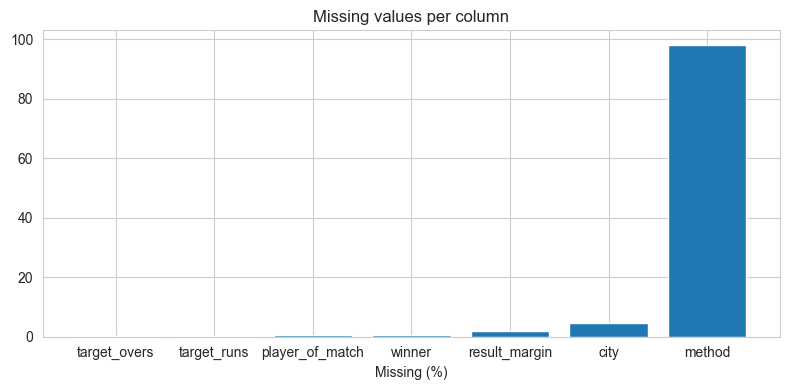

In [6]:
null_df = pd.DataFrame({'missing_count': null_series,'missing_pct': null_pct})
null_df=null_df[null_df['missing_count']>0]
null_df = null_df.sort_values('missing_pct', ascending=True)
print(null_df)
plt.figure(figsize=(8, 4))
plt.bar(null_df.index, null_df['missing_pct'])
plt.xlabel('Missing (%)')
plt.title('Missing values per column')
plt.tight_layout()
plt.show()

In [7]:
df['city'] = df['city'].fillna('Unknown')
df['winner'] = df['winner'].fillna('No Result')
df['player_of_match'] = df['player_of_match'].fillna('N/A')
df['method'] = df['method'].fillna('Normal')
df['result_margin'] = df['result_margin'].fillna(0)
df['target_runs'] = df['target_runs'].fillna(0)
df['target_overs'] = df['target_overs'].fillna(0)


What I decided for each column and why:

city        → filled with 'Unknown' because few of the matches were held in Dubai and other places during covid

winner      → filled with 'No Result' because there were no winners

method      → filled with 'Normal' because dls only applies to rain affected games

result_margin → filled with 0 because these are tied/no-result games, fill with 0
|
I did NOT drop any rows because all the rows had data and dropping it would serve no benefit

In [8]:
print(df.isnull().sum())


id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64


# Task 3: Bar chart of total wins per team

In [9]:
name_map = {
    'Delhi Daredevils'           : 'Delhi Capitals',
    'Kings XI Punjab'            : 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants'    : 'Rising Pune Supergiant',
}
df['winner'] = df['winner'].replace(name_map)
df['team1']  = df['team1'].replace(name_map)
df['team2']  = df['team2'].replace(name_map)

In [10]:
wins = df[df['winner'] != 'No Result']['winner'].value_counts()
print(wins)
wins=wins[-1::-1]

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


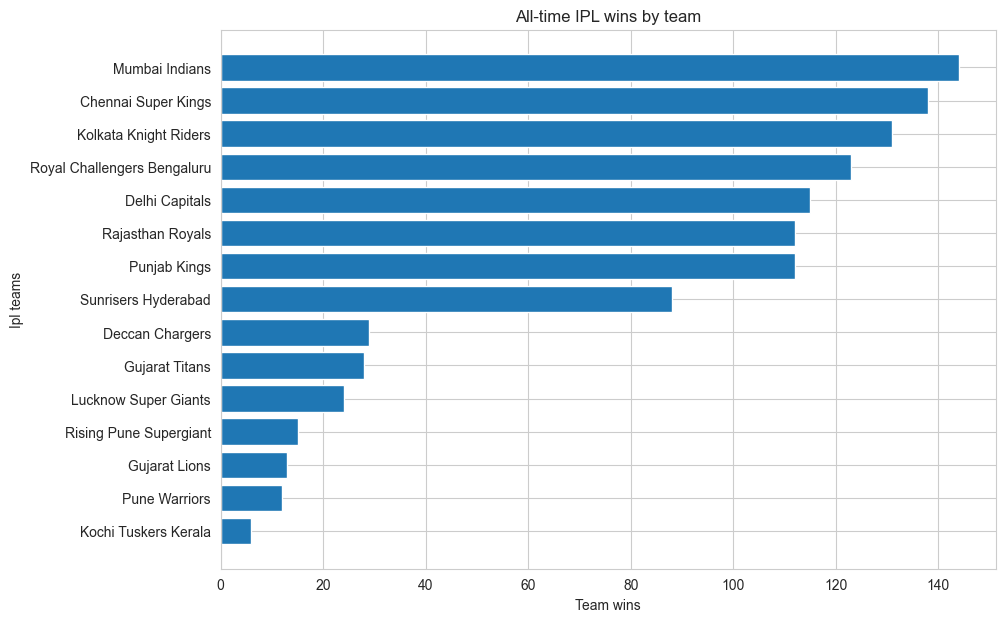

In [11]:
plt.figure(figsize=(10,7))
plt.barh(wins.index,wins)
plt.ylabel("Ipl teams")
plt.xlabel('Team wins')
plt.title('All-time IPL wins by team')
plt.show()

Here we can see that mumbai indians has the most wins in all of the ipl matches follwed by csk and kkr

gujarat lions,pune warriors and kochi tuskers have the least wins due to fact they were in the least ipl seasons

# Task 4: Distribution analysis (histograms, boxplots)

In [12]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,Normal,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,Normal,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,Normal,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,Normal,BF Bowden,K Hariharan


In [13]:
target_run=df[df['target_runs']!=0]
target_run=target_run['target_runs']
target_run

0       223.0
1       241.0
2       130.0
3       166.0
4       111.0
        ...  
1090    215.0
1091    160.0
1092    173.0
1093    176.0
1094    114.0
Name: target_runs, Length: 1092, dtype: float64

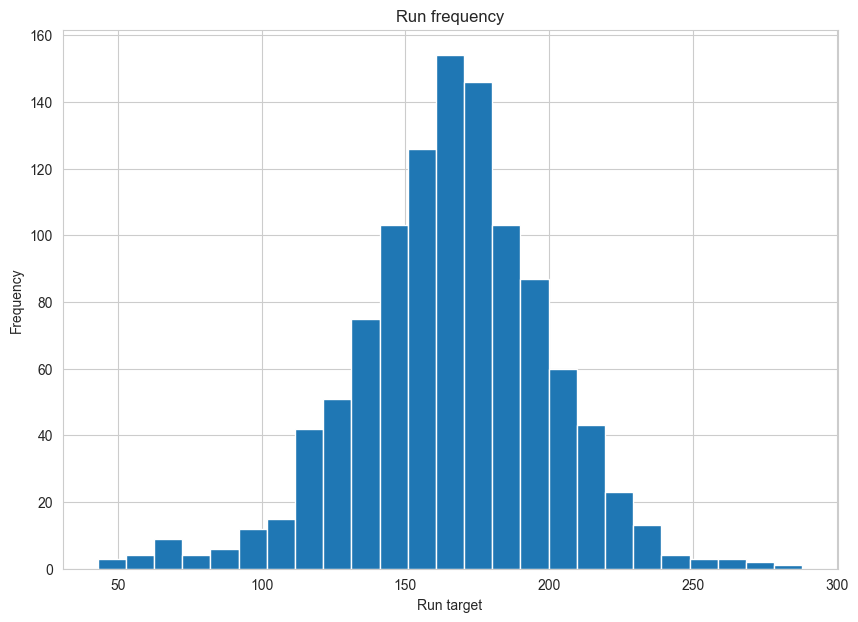

In [14]:
plt.figure(figsize=(10,7),)
plt.hist(target_run,bins=25)
plt.xlabel("Run target")
plt.ylabel('Frequency')
plt.title('Run frequency')
plt.show()

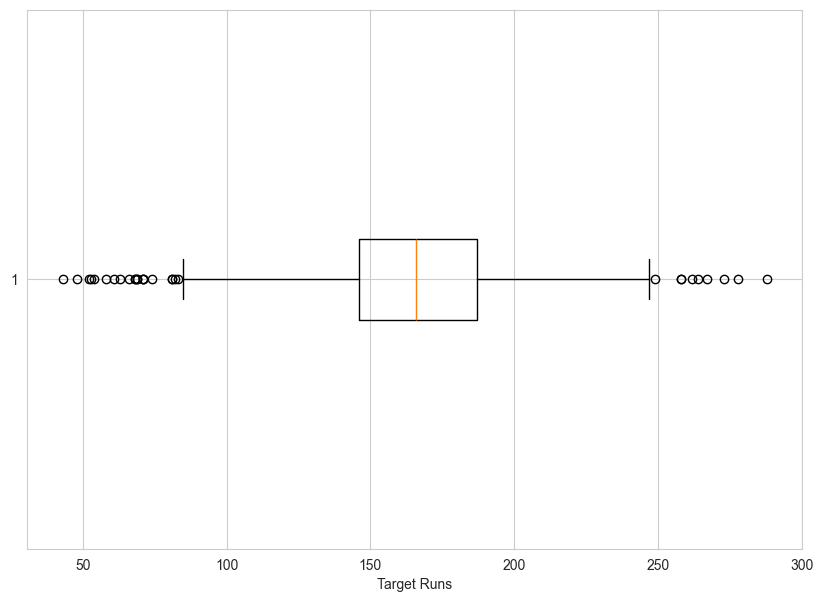

In [15]:
plt.figure(figsize=(10,7))
plt.boxplot(target_run,orientation='horizontal')
plt.xlabel('Target Runs')
plt.show()

Based on the data we know that the graph is roughly symmetrical and on avg the target runs are in between 150 and 170

from the boxplot we can see the target score > 250 and target score< 90 rarely occurs as they are the outliers

# Task 5:
## We are going to test a famous IPL hypothesis: Over the years, teams have developed a strong preference for fielding first (chasing) rather than batting first.

In [16]:
toss_pref=df.groupby(['season', 'toss_decision']).size().unstack()
toss_pref

toss_decision,bat,field
season,,
2007/08,26,32
2009,35,22
2009/10,39,21
2011,25,48
2012,37,37
2013,45,31
2014,19,41
2015,25,34
2016,11,49


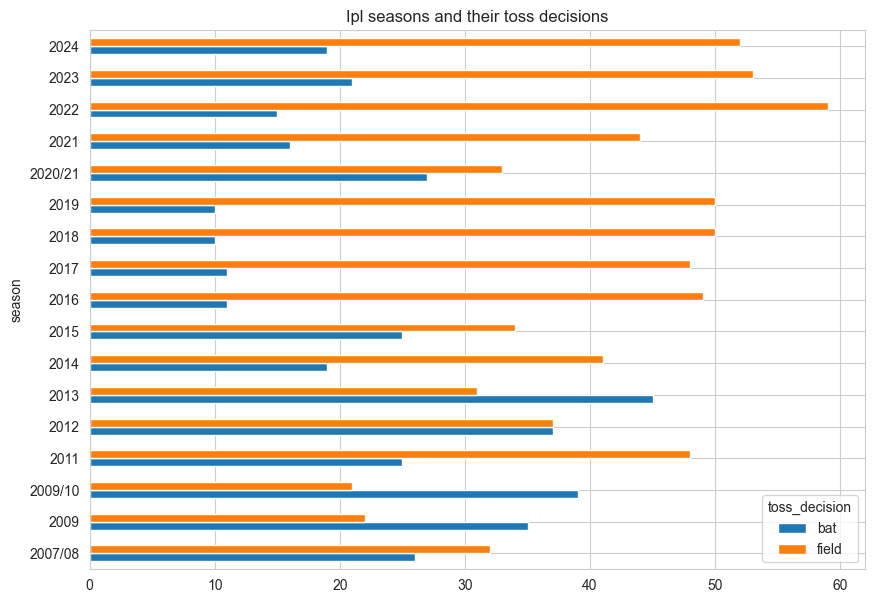

In [17]:
toss_pref.plot(kind='barh',figsize=(10,7),title='Ipl seasons and their toss decisions')
plt.show()

The hypothesis seems to be true as after 2015 we see the difference between bat and field is massive

# Task 6: Time/trend analysis

In [18]:
df.groupby('season')['target_runs'].mean()


season
2007/08    159.775862
2009       148.807018
2009/10    165.783333
2011       151.931507
2012       158.540541
2013       156.894737
2014       162.383333
2015       161.915254
2016       160.783333
2017       165.406780
2018       170.200000
2019       167.733333
2020/21    170.500000
2021       160.316667
2022       172.121622
2023       180.918919
2024       190.591549
Name: target_runs, dtype: float64

In [19]:
avg_runs_per_season=df[df['target_runs'] != 0]
avg_runs_per_season=avg_runs_per_season.groupby('season')['target_runs'].mean()
avg_runs_per_season

season
2007/08    159.775862
2009       148.807018
2009/10    165.783333
2011       154.041667
2012       158.540541
2013       156.894737
2014       162.383333
2015       164.706897
2016       160.783333
2017       165.406780
2018       170.200000
2019       167.733333
2020/21    170.500000
2021       160.316667
2022       172.121622
2023       183.397260
2024       190.591549
Name: target_runs, dtype: float64

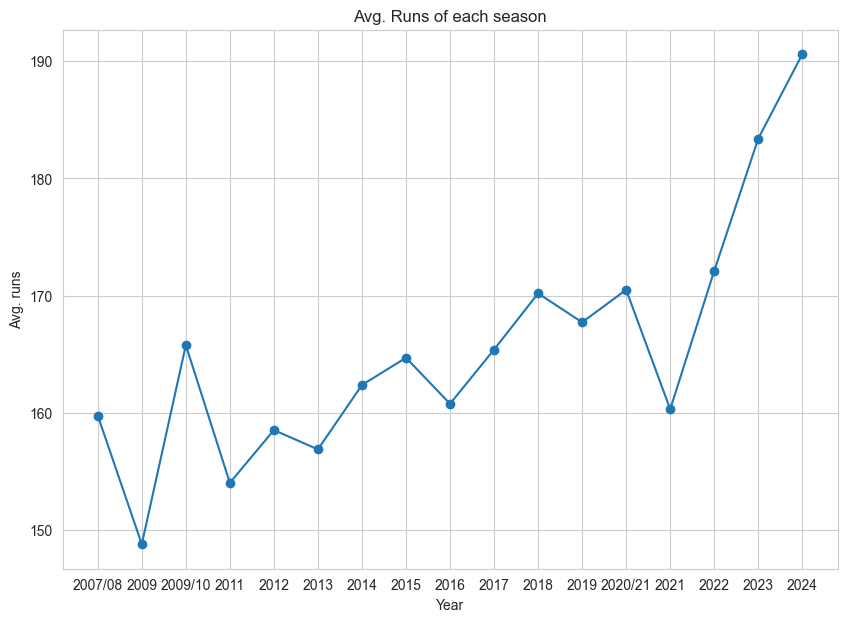

In [20]:
plt.figure(figsize=(10,7))
plt.plot(avg_runs_per_season.index, avg_runs_per_season, marker='o')
plt.xlabel('Year')
plt.ylabel('Avg. runs')
plt.title('Avg. Runs of each season')
plt.show()

the general trend was run were gradually increasing each year except 2009 & 2021 and there was a sudden increase after 2021

# Task 7: Correlation Heatmap

In [21]:
correlation=df.corr(numeric_only=True)

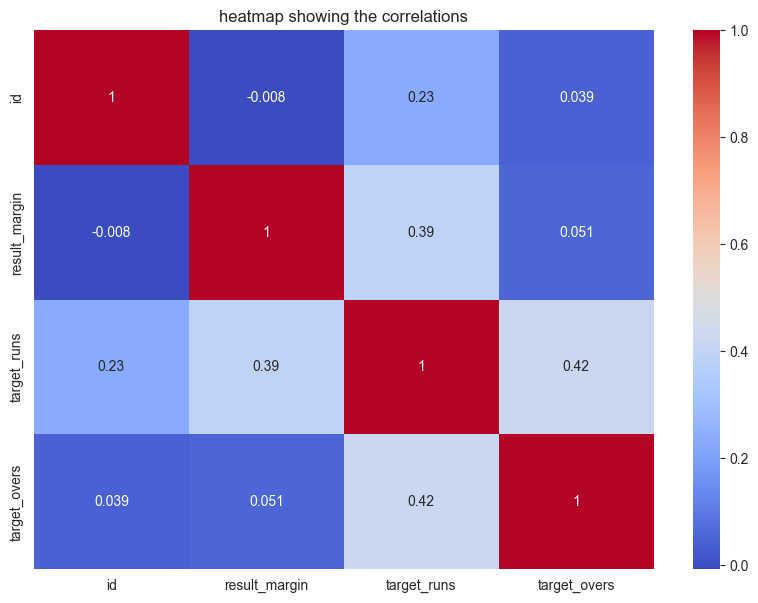

In [22]:
plt.figure(figsize=(10,7))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('heatmap showing the correlations')
plt.show()

we see a positive correlation between target_runs and target_overs as well as one with target_runs with result_margin however they both are moderately correlated

the rest all are not correlated at all

# Task 8: Feature Engineering

In [23]:
df['is_toss_winner_match_winner']=df['toss_winner']==df['winner']
df['is_toss_winner_match_winner']=df['is_toss_winner_match_winner'].astype('int8')
df[['toss_winner', 'winner', 'is_toss_winner_match_winner']].head()

,toss_winner,winner,is_toss_winner_match_winner
0,Royal Challengers Bangalore,Kolkata Knight Riders,0
1,Chennai Super Kings,Chennai Super Kings,1
2,Rajasthan Royals,Delhi Capitals,0
3,Mumbai Indians,Royal Challengers Bengaluru,0
4,Deccan Chargers,Kolkata Knight Riders,0


In [24]:
df['close_match']=((df['result']=='runs')&(df['result_margin']<10))|((df['result']=='wickets')&(df['result_margin']<3))
df['close_match']=df['close_match'].astype('int8')
df[['result','result_margin','close_match']].head()

,result,result_margin,close_match
0,runs,140.0,0
1,runs,33.0,0
2,wickets,9.0,0
3,wickets,5.0,0
4,wickets,5.0,0


For a ml model the two new features would valuable as we now have numerical data on if the toss winner proceeds to win the match or not and if the match was existing or not and since the ml model needs numerical values this will help in that

# Task 9: Hypothesis Testing

In [25]:
from scipy.stats import chi2_contingency
contingency=pd.crosstab(df['toss_decision'],df['is_toss_winner_match_winner'])
print(contingency)

is_toss_winner_match_winner    0    1
toss_decision                        
bat                          247  144
field                        425  279


In [26]:
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p_value:.6f}")

p-value: 0.396625


Null Hypothesis: The toss decision (bat/field) has no effect on whether the toss winner wins the match.

Alternative Hypothesis : The toss decision does have an effect.

p-value: 0.39

Conclusion: Since the p-value (0.39) is greater than our alpha level of 0.05, we fail to reject the null hypothesis. Statistically speaking, the decision to bat or field first does not significantly impact a team's chances of winning the match.

# Task 10: final thoughts

### IPL 2008-2024 EDA: Final Executive Summary

**1. The Dominant Franchise:**
Throughout the dataset, the most successful team overall was mumbai indians, followed closely by chennai super kings.

**2. The Target Runs Trend:**
Over the years, the average target score has generally 150 to 170, with a notable anomaly/spike occurring after the 2022 season.

**3. The Toss Decision Myth:**
Despite a strong visual preference for teams choosing to field first after 2015, our Chi-Square hypothesis test (p-value: 0.39) mathematically proved that the toss decision actually has no effect on winning the match!

**4. The Value of Feature Engineering:**
By creating the `close_match` and `is_toss_winner_match_winner` columns, we translated abstract cricket concepts into numerical data, which will be incredibly useful for training future Machine Learning models.